In [1]:
import pandas as pd
df = pd.read_csv("2016.csv")
print(df.shape)

(157, 13)


In [2]:
import numpy as np

df.loc[2, "Happiness Score"] = None
df.loc[5, "Economy (GDP per Capita)"] = None
df.loc[8, "Region"] = None

print("Mess introduced successfully!")
print(df.isnull().sum())

Mess introduced successfully!
Country                          0
Region                           1
Happiness Rank                   0
Happiness Score                  1
Lower Confidence Interval        0
Upper Confidence Interval        0
Economy (GDP per Capita)         1
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64


In [3]:
df_dropped = df.dropna()
print(df_dropped.shape)

(154, 13)


In [4]:
df_filled = df.fillna({
    "Happiness Score": df["Happiness Score"].mean(),
    "Economy (GDP per Capita)": df["Economy (GDP per Capita)"].mean(),
    "Region": "Unknown"
})
print(df_filled.isnull().sum())

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Lower Confidence Interval        0
Upper Confidence Interval        0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64


In [5]:
df_filled = df_filled.rename(columns={
    "Economy (GDP per Capita)": "GDP",
    "Health (Life Expectancy)": "Health",
    "Trust (Government Corruption)": "Trust"
})
print(df_filled.columns)

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Lower Confidence Interval', 'Upper Confidence Interval', 'GDP',
       'Family', 'Health', 'Freedom', 'Trust', 'Generosity',
       'Dystopia Residual'],
      dtype='object')


In [6]:
# Check for duplicates first
print("Duplicates found:", df_filled.duplicated().sum())

# Remove them
df_filled = df_filled.drop_duplicates()
print("After removing duplicates:", df_filled.shape)

Duplicates found: 0
After removing duplicates: (157, 13)


In [7]:
# Check current data types
print(df_filled.dtypes)

# Example — convert Happiness Rank to integer if needed
df_filled["Happiness Rank"] = df_filled["Happiness Rank"].astype(int)
print("Done!")

Country                       object
Region                        object
Happiness Rank                 int64
Happiness Score              float64
Lower Confidence Interval    float64
Upper Confidence Interval    float64
GDP                          float64
Family                       float64
Health                       float64
Freedom                      float64
Trust                        float64
Generosity                   float64
Dystopia Residual            float64
dtype: object
Done!


In [1]:
import pandas as pd
df = pd.read_csv("2016.csv")
print(df.shape)

(157, 13)


Matplotlib is building the font cache; this may take a moment.


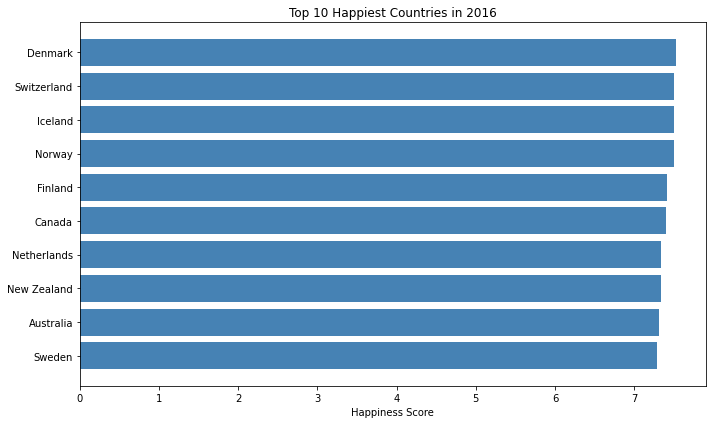

In [2]:
import matplotlib.pyplot as plt

# Get top 10 happiest countries
top10 = df.nlargest(10, "Happiness Score")

# Build the bar chart
plt.figure(figsize=(10, 6))
plt.barh(top10["Country"], top10["Happiness Score"], color="steelblue")
plt.xlabel("Happiness Score")
plt.title("Top 10 Happiest Countries in 2016")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

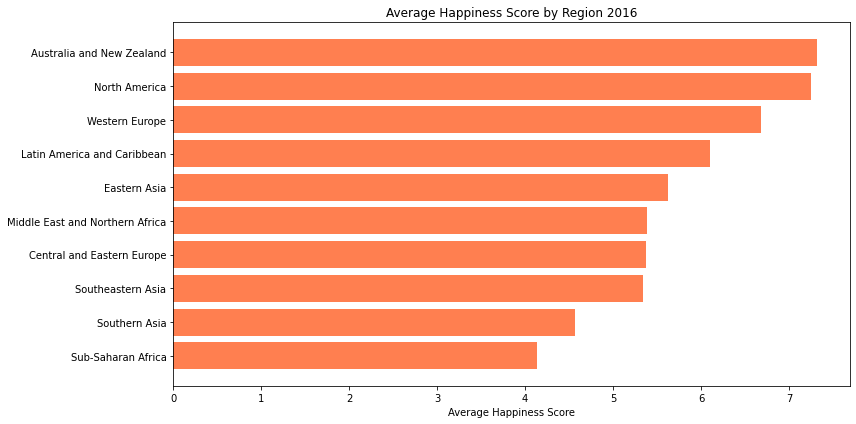

In [3]:
# Average happiness by region
regional = df.groupby("Region")["Happiness Score"].mean()
regional = regional.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(regional.index, regional.values, color="coral")
plt.xlabel("Average Happiness Score")
plt.title("Average Happiness Score by Region 2016")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

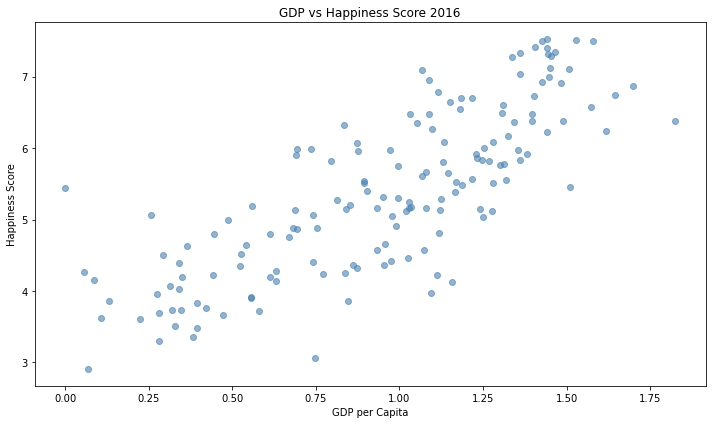

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Economy (GDP per Capita)"], df["Happiness Score"], 
            color="steelblue", alpha=0.6)
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.title("GDP vs Happiness Score 2016")
plt.tight_layout()
plt.show()

In [ ]:
d